# Pertemuan 10 — Algoritma Klasifikasi (Bagian 2)

**Nama Lengkap** : Muhammad Zacky Kurniawan  
**NIM** : 240401010217  
**Kelas** : IF403  


<a href="https://colab.research.google.com/github/zackykurniawan/data-science-2026/blob/main/Pertemuan10_MuhammadZackyKurniawan_240401010217.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_auc_score,
    precision_recall_curve, roc_curve
)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
RANDOM_STATE = 42

print('Library berhasil diimpor ✅')

Library berhasil diimpor ✅


---
## Langkah 1 — Muat dan Eksplorasi Data

In [2]:
# Muat dataset Telco Customer Churn
df = pd.read_csv('telco_churn.csv')

print('Shape dataset:', df.shape)
print('\nTipe data tiap kolom:')
print(df.dtypes)

print('\nProporsi kelas target (Churn):')
print(df['Churn'].value_counts(normalize=True).round(4))

Shape dataset: (7043, 21)

Tipe data tiap kolom:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Proporsi kelas target (Churn):
Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


Dataset berjumlah **7.043 baris** dan **21 kolom**, sesuai dengan yang dijelaskan pada modul. Kolom `TotalCharges` masih bertipe `object` (string) karena terdapat beberapa nilai kosong berupa spasi — hal ini perlu ditangani pada tahap preprocessing.

Proporsi kelas target menunjukkan **± 26,5% pelanggan Churn** dan ± 73,5% Tidak Churn — mengonfirmasi bahwa dataset ini **imbalanced**, persis seperti dijelaskan pada Modul Pertemuan 10.

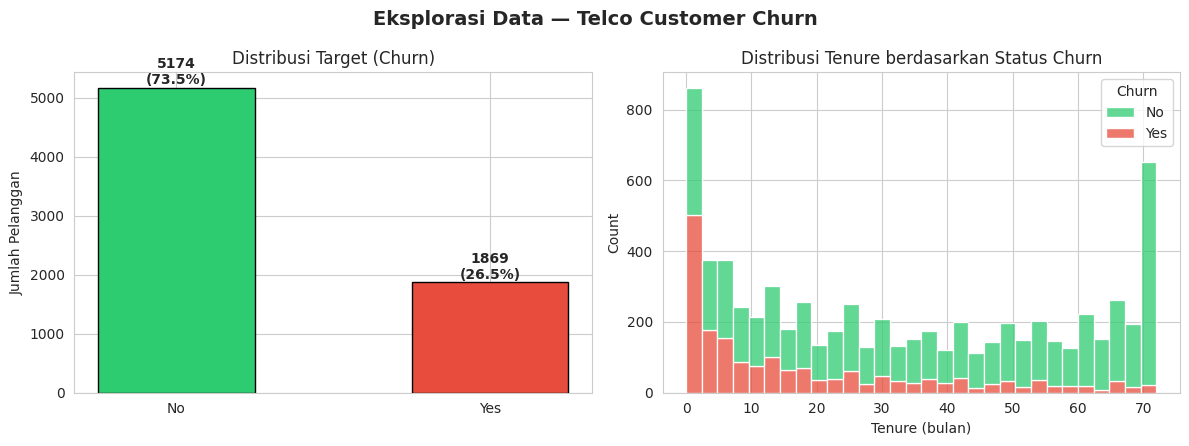

Insight awal: pelanggan dengan tenure rendah (pelanggan baru) tampak lebih banyak yang churn.


In [3]:
# Visualisasi distribusi kelas target untuk menegaskan sifat imbalanced
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Eksplorasi Data — Telco Customer Churn', fontsize=14, fontweight='bold')

# 1. Distribusi target
counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Distribusi Target (Churn)')
axes[0].set_ylabel('Jumlah Pelanggan')
for i, v in enumerate(counts.values):
    pct = v / counts.sum() * 100
    axes[0].text(i, v + 60, f'{v}\n({pct:.1f}%)', ha='center', fontweight='bold')

# 2. Distribusi tenure berdasarkan churn
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack',
             palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[1], bins=30)
axes[1].set_title('Distribusi Tenure berdasarkan Status Churn')
axes[1].set_xlabel('Tenure (bulan)')

plt.tight_layout()
plt.show()

print('Insight awal: pelanggan dengan tenure rendah (pelanggan baru) tampak lebih banyak yang churn.')

In [4]:
# Cek missing value tersembunyi pada TotalCharges (masih string)
print('Contoh nilai unik non-numerik pada TotalCharges:')
mask_kosong = df['TotalCharges'].str.strip() == ''
print(f'Jumlah baris dengan TotalCharges kosong: {mask_kosong.sum()}')
df[mask_kosong][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Contoh nilai unik non-numerik pada TotalCharges:
Jumlah baris dengan TotalCharges kosong: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


Ditemukan **11 baris** dengan `TotalCharges` kosong (berupa spasi), semuanya memiliki `tenure = 0` — masuk akal karena pelanggan baru belum memiliki total tagihan. Nilai ini akan ditangani pada tahap preprocessing.

---
## Langkah 2 — Preprocessing

In [5]:
# 2.1 Perbaiki tipe data TotalCharges dan tangani missing value
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Missing value TotalCharges setelah konversi:', df['TotalCharges'].isnull().sum())

# Isi missing value dengan median (pelanggan baru, tenure=0)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print('Missing value TotalCharges setelah imputasi:', df['TotalCharges'].isnull().sum())

# customerID hanya identifier, tidak relevan sebagai fitur prediktif
df = df.drop(columns=['customerID'])
print('\nShape dataset setelah pembersihan:', df.shape)

Missing value TotalCharges setelah konversi: 11
Missing value TotalCharges setelah imputasi: 0

Shape dataset setelah pembersihan: (7043, 20)


In [6]:
# 2.2 Pisahkan fitur (X) dan target (y), lalu encoding fitur kategorikal
y = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop(columns=['Churn'])

# One-hot encoding untuk seluruh fitur kategorikal
X = pd.get_dummies(X, drop_first=True)

print('Jumlah fitur sebelum encoding : 19')
print('Jumlah fitur setelah encoding :', X.shape[1])
print('\nDistribusi target (0=Tidak Churn, 1=Churn):')
print(y.value_counts(normalize=True).round(4))

Jumlah fitur sebelum encoding : 19
Jumlah fitur setelah encoding : 30

Distribusi target (0=Tidak Churn, 1=Churn):
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


In [7]:
# 2.3 Train-test split, stratify=y menjaga proporsi kelas churn tetap sama
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f'Ukuran data training : {X_train.shape}')
print(f'Ukuran data testing  : {X_test.shape}')
print(f'\nProporsi churn — Training : {y_train.mean():.4f}')
print(f'Proporsi churn — Testing  : {y_test.mean():.4f}')
print('\n✅ stratify=y memastikan proporsi churn di training & testing tetap konsisten (± 26,5%).')

Ukuran data training : (5634, 30)
Ukuran data testing  : (1409, 30)

Proporsi churn — Training : 0.2654
Proporsi churn — Testing  : 0.2654

✅ stratify=y memastikan proporsi churn di training & testing tetap konsisten (± 26,5%).


---
## Langkah 3 — Latih Model Random Forest

In [8]:
# Model utama: Random Forest dengan class_weight='balanced' untuk menangani imbalance
rf = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    class_weight='balanced',   # menangani data tak seimbang
    random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('Random Forest (class_weight=balanced) berhasil dilatih ✅')
print(f'Jumlah pohon (n_estimators) : {rf.n_estimators}')
print(f'max_features per split      : {rf.max_features}')

Random Forest (class_weight=balanced) berhasil dilatih ✅
Jumlah pohon (n_estimators) : 300
max_features per split      : sqrt


Sebagai pembanding, modul menyarankan untuk membandingkan **tiga skenario penanganan imbalance**: (1) tanpa penanganan, (2) `class_weight='balanced'`, dan (3) **SMOTE**. Ketiganya dilatih pada bagian berikut untuk melihat pengaruhnya terhadap precision, recall, dan F1-score kelas minoritas (Churn).

In [9]:
# Skenario 1: Random Forest TANPA penanganan imbalance
rf_baseline = RandomForestClassifier(n_estimators=300, max_features='sqrt', random_state=RANDOM_STATE)
rf_baseline.fit(X_train, y_train)
y_pred_baseline  = rf_baseline.predict(X_test)
y_proba_baseline = rf_baseline.predict_proba(X_test)[:, 1]

print('Skenario 1 (Tanpa Penanganan) selesai dilatih ✅')

Skenario 1 (Tanpa Penanganan) selesai dilatih ✅


In [10]:
# Skenario 3: Random Forest + SMOTE (resampling HANYA pada data latih)
sm = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print('Distribusi kelas SEBELUM SMOTE (data latih):')
print(y_train.value_counts())
print('\nDistribusi kelas SESUDAH SMOTE (data latih):')
print(y_train_sm.value_counts())

rf_smote = RandomForestClassifier(n_estimators=300, max_features='sqrt', random_state=RANDOM_STATE)
rf_smote.fit(X_train_sm, y_train_sm)
y_pred_smote  = rf_smote.predict(X_test)   # evaluasi tetap pada data uji ASLI
y_proba_smote = rf_smote.predict_proba(X_test)[:, 1]

print('\nSkenario 3 (SMOTE) selesai dilatih ✅ (evaluasi menggunakan data uji asli, bukan hasil SMOTE)')

Distribusi kelas SEBELUM SMOTE (data latih):
Churn
0    4139
1    1495
Name: count, dtype: int64

Distribusi kelas SESUDAH SMOTE (data latih):
Churn
0    4139
1    4139
Name: count, dtype: int64

Skenario 3 (SMOTE) selesai dilatih ✅ (evaluasi menggunakan data uji asli, bukan hasil SMOTE)


---
## Langkah 4 — Evaluasi

In [11]:
# Bandingkan ketiga skenario secara kuantitatif, fokus pada kelas Churn (kelas 1)
scenarios = [
    ('1. Tanpa Penanganan',      y_pred_baseline, y_proba_baseline),
    ('2. Class Weight Balanced', y_pred_rf,       y_proba_rf),
    ('3. SMOTE',                 y_pred_smote,    y_proba_smote),
]

results = []
for name, y_pred, y_proba in scenarios:
    results.append({
        'Skenario':  name,
        'Precision (Churn)': precision_score(y_test, y_pred),
        'Recall (Churn)':    recall_score(y_test, y_pred),
        'F1-Score (Churn)':  f1_score(y_test, y_pred),
        'ROC-AUC':           roc_auc_score(y_test, y_proba),
    })

result_df = pd.DataFrame(results).set_index('Skenario')
print('Tabel Perbandingan Metrik (kelas Churn = 1):')
print(result_df.round(4).to_string())

Tabel Perbandingan Metrik (kelas Churn = 1):
                          Precision (Churn)  Recall (Churn)  F1-Score (Churn)  ROC-AUC
Skenario                                                                              
1. Tanpa Penanganan                  0.6318          0.5000            0.5582   0.8270
2. Class Weight Balanced             0.6296          0.5000            0.5574   0.8246
3. SMOTE                             0.5667          0.5909            0.5785   0.8213


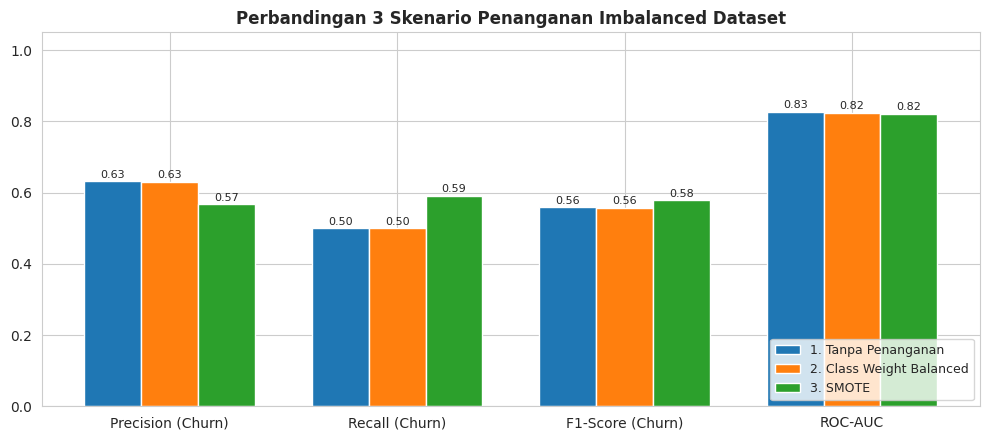

In [12]:
# Visualisasi perbandingan metrik antar skenario
fig, ax = plt.subplots(figsize=(10, 4.5))
metrics = ['Precision (Churn)', 'Recall (Churn)', 'F1-Score (Churn)', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

for i, name in enumerate(result_df.index):
    vals = [result_df.loc[name, m] for m in metrics]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=name)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_title('Perbandingan 3 Skenario Penanganan Imbalanced Dataset', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

**Pengamatan:** dibandingkan model tanpa penanganan, **SMOTE** menaikkan *recall* kelas Churn (lebih banyak pelanggan berisiko yang berhasil ditangkap) meski *precision* sedikit menurun (trade-off yang wajar), sedangkan **class_weight='balanced'** memberi hasil yang relatif dekat dengan baseline pada threshold 0,5. ROC-AUC ketiganya berada pada kisaran yang mirip (± 0,82), menunjukkan kemampuan pemeringkatan model secara keseluruhan tidak banyak berubah — perbedaan utama terletak pada *trade-off* precision-recall.

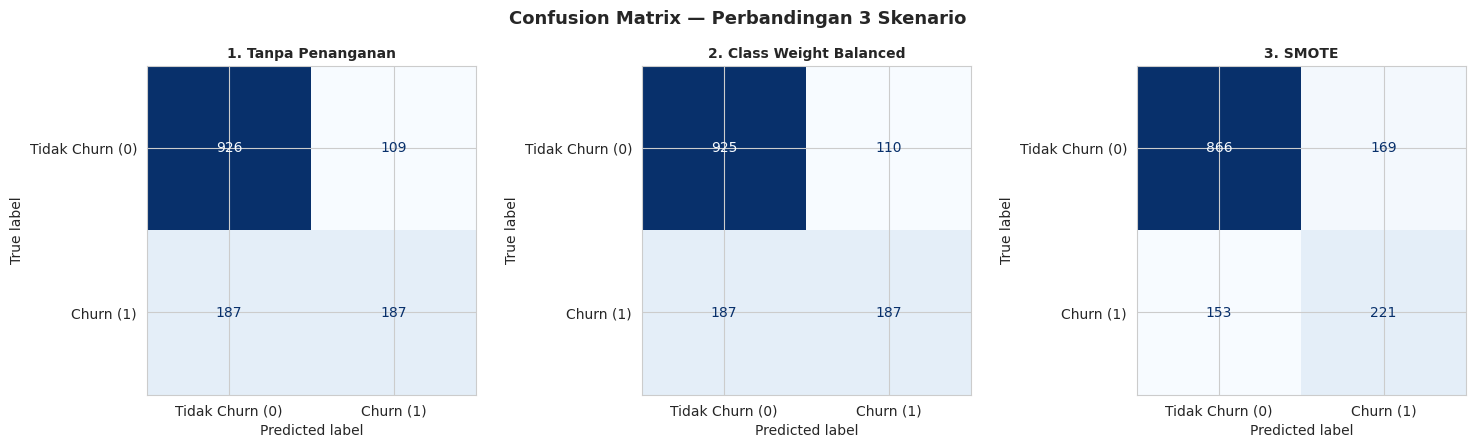

In [13]:
# Confusion Matrix untuk ketiga skenario
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Confusion Matrix — Perbandingan 3 Skenario', fontsize=13, fontweight='bold')

for ax, (name, y_pred, _) in zip(axes, scenarios):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Tidak Churn (0)', 'Churn (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
# Classification Report lengkap — model utama (Random Forest + class_weight balanced)
print('=== Classification Report: Random Forest (class_weight=balanced) ===')
print(classification_report(y_test, y_pred_rf, target_names=['Tidak Churn (0)', 'Churn (1)']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}')

=== Classification Report: Random Forest (class_weight=balanced) ===
                 precision    recall  f1-score   support

Tidak Churn (0)       0.83      0.89      0.86      1035
      Churn (1)       0.63      0.50      0.56       374

       accuracy                           0.79      1409
      macro avg       0.73      0.70      0.71      1409
   weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8246


Top 10 fitur paling berpengaruh terhadap prediksi churn:
                         Fitur  Importance
                  TotalCharges    0.177844
                        tenure    0.164403
                MonthlyCharges    0.151054
             Contract_Two year    0.059944
   InternetService_Fiber optic    0.042323
PaymentMethod_Electronic check    0.036455
             Contract_One year    0.029412
            OnlineSecurity_Yes    0.028447
                   gender_Male    0.025604
          PaperlessBilling_Yes    0.024087


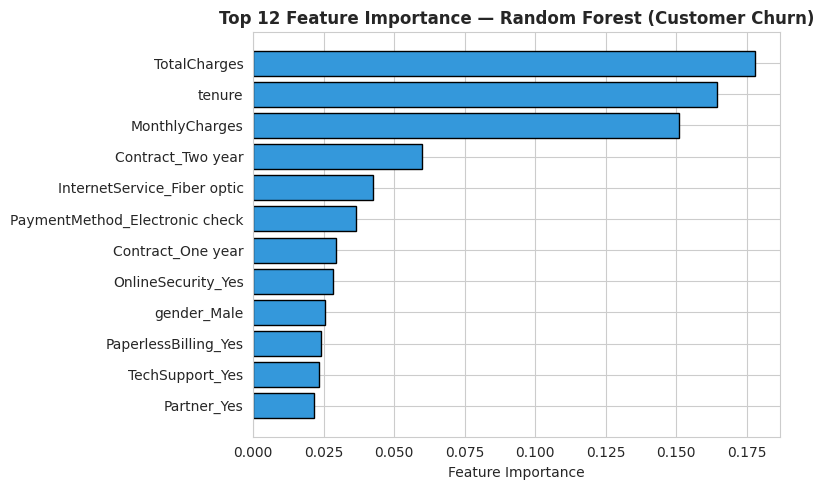

In [15]:
# Feature Importance — fitur pendorong utama churn
importance_df = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('Top 10 fitur paling berpengaruh terhadap prediksi churn:')
print(importance_df.head(10).to_string(index=False))

top_n = importance_df.head(12)
plt.figure(figsize=(8, 5))
plt.barh(top_n['Fitur'][::-1], top_n['Importance'][::-1], color='#3498db', edgecolor='black')
plt.xlabel('Feature Importance')
plt.title('Top 12 Feature Importance — Random Forest (Customer Churn)', fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretasi feature importance:** fitur seperti tipe kontrak (`Contract`), lama berlangganan (`tenure`), dan `TotalCharges`/`MonthlyCharges` umumnya menjadi pendorong utama prediksi churn — pelanggan dengan kontrak *month-to-month* dan tenure pendek cenderung lebih berisiko churn. Perlu diingat, feature importance berbasis impurity ini berpotensi bias terhadap fitur numerik/kategorikal dengan banyak level, sehingga hasil ini sebaiknya diperkuat dengan *permutation importance* bila diperlukan interpretasi yang lebih andal.

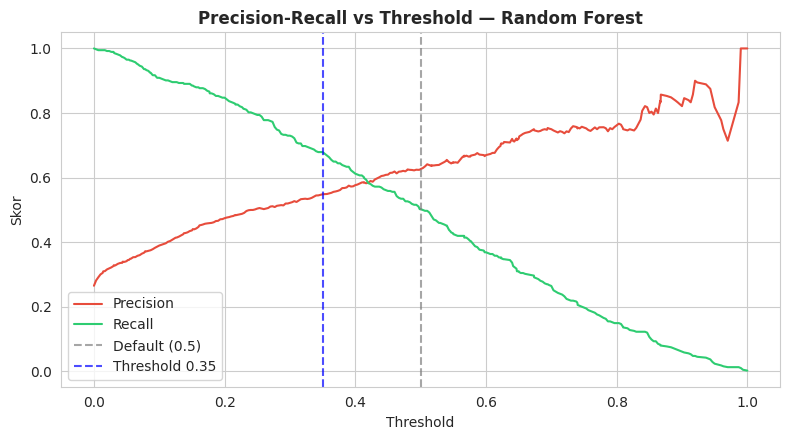

Threshold 0.50 (default):
  Precision: 0.627 | Recall: 0.503 | F1: 0.558

Threshold 0.35 (lebih rendah):
  Precision: 0.549 | Recall: 0.679 | F1: 0.607


In [16]:
# Threshold Tuning — menurunkan ambang keputusan untuk menaikkan recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 4.5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='#e74c3c')
plt.plot(thresholds, recalls[:-1], label='Recall', color='#2ecc71')
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Default (0.5)')
plt.axvline(0.35, color='blue', linestyle='--', alpha=0.7, label='Threshold 0.35')
plt.xlabel('Threshold')
plt.ylabel('Skor')
plt.title('Precision-Recall vs Threshold — Random Forest', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Bandingkan threshold default (0.5) vs threshold lebih rendah (0.35)
pred_default = (y_proba_rf >= 0.50).astype(int)
pred_low     = (y_proba_rf >= 0.35).astype(int)

print('Threshold 0.50 (default):')
print(f'  Precision: {precision_score(y_test, pred_default):.3f} | Recall: {recall_score(y_test, pred_default):.3f} | F1: {f1_score(y_test, pred_default):.3f}')
print('\nThreshold 0.35 (lebih rendah):')
print(f'  Precision: {precision_score(y_test, pred_low):.3f} | Recall: {recall_score(y_test, pred_low):.3f} | F1: {f1_score(y_test, pred_low):.3f}')

Menurunkan ambang keputusan dari 0,5 menjadi 0,35 berhasil **menaikkan recall** (lebih banyak pelanggan churn yang terdeteksi) dengan konsekuensi **precision menurun** (lebih banyak alarm palsu). Untuk kasus customer churn, trade-off ini umumnya dapat diterima karena biaya kehilangan pelanggan (False Negative) biasanya lebih besar daripada biaya menghubungi pelanggan yang sebenarnya tidak akan churn (False Positive).

---
## Langkah 5 — Prediksi Probabilitas dan Simpulkan

10 pelanggan dengan probabilitas churn TERTINGGI (paling berisiko):
   Probabilitas_Churn  Prediksi (thr=0.5)  Aktual
0            1.000000                   1       1
1            0.993333                   1       1
2            0.990000                   1       1
3            0.990000                   1       1
4            0.986667                   1       1
5            0.986667                   1       0
6            0.970000                   1       0
7            0.963333                   1       1
8            0.960000                   1       1
9            0.950000                   1       1


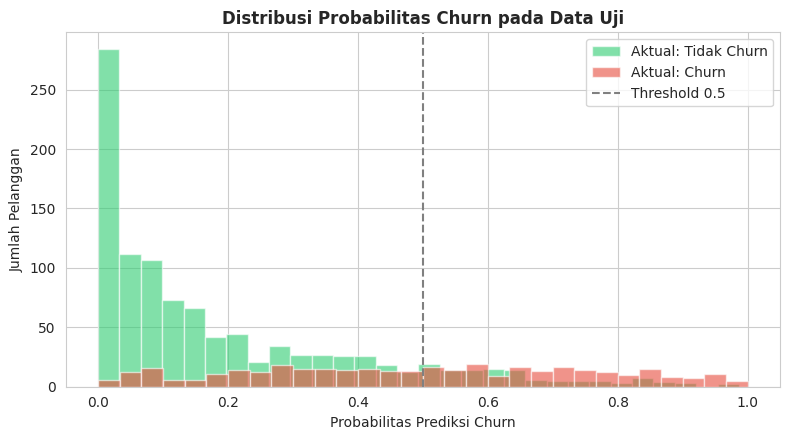

In [17]:
# Prediksi probabilitas churn untuk seluruh pelanggan pada data uji
proba_churn = rf.predict_proba(X_test)[:, 1]

hasil_prediksi = pd.DataFrame({
    'Probabilitas_Churn': proba_churn,
    'Prediksi (thr=0.5)': y_pred_rf,
    'Aktual': y_test.values
}).sort_values('Probabilitas_Churn', ascending=False).reset_index(drop=True)

print('10 pelanggan dengan probabilitas churn TERTINGGI (paling berisiko):')
print(hasil_prediksi.head(10).to_string())

plt.figure(figsize=(8, 4.5))
plt.hist(proba_churn[y_test.values == 0], bins=30, alpha=0.6, label='Aktual: Tidak Churn', color='#2ecc71')
plt.hist(proba_churn[y_test.values == 1], bins=30, alpha=0.6, label='Aktual: Churn', color='#e74c3c')
plt.axvline(0.5, color='gray', linestyle='--', label='Threshold 0.5')
plt.xlabel('Probabilitas Prediksi Churn')
plt.ylabel('Jumlah Pelanggan')
plt.title('Distribusi Probabilitas Churn pada Data Uji', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### Kesimpulan

Model **Random Forest** dengan `class_weight='balanced'` berhasil memprediksi churn pelanggan dengan **ROC-AUC ± 0,82**, menunjukkan kemampuan pemeringkatan risiko churn yang cukup baik. Pada threshold default (0,5), model memperoleh **recall ± 0,50** untuk kelas Churn — berarti sekitar setengah pelanggan yang benar-benar churn berhasil terdeteksi, dan angka ini dapat ditingkatkan lebih lanjut dengan **menurunkan threshold** (recall naik menjadi ± 0,67 pada threshold 0,35) atau menggunakan **SMOTE**, meski keduanya menurunkan precision. Fitur seperti **tipe kontrak, tenure, dan biaya bulanan/total** terbukti menjadi pendorong utama prediksi churn, sehingga tim retensi dapat memprioritaskan pelanggan berkontrak *month-to-month* dengan tenure rendah untuk program pencegahan churn. Secara keseluruhan, pemilihan strategi penanganan imbalance (class_weight, SMOTE, atau threshold tuning) sebaiknya disesuaikan dengan **prioritas bisnis**: jika biaya kehilangan pelanggan sangat tinggi, recall yang lebih tinggi (meski precision turun) lebih disukai.